In [32]:
import torch
import numpy as np
import normflows as nf
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
from conditional_gmm import ConditionalGMM
from posterior_manifold import PosteriorManifold, FisherPosteriorManifold, FisherLogPosteriorManifold, NewFisherLogPosteriorManifold
from riemannian_geometry import lerp
from matplotlib import cm

In [3]:
# Define 2D Gaussian base distribution
base = nf.distributions.base.DiagGaussian(2)
num_layers = 32
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([1, 64, 64, 2], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(2, mode='swap'))

# Construct flow model
model = nf.NormalizingFlow(base, flows).cuda()

In [4]:
X = torch.linspace(-2, 2, 40)
Y = torch.linspace(-2, 2, 40)
grid = torch.stack(torch.meshgrid(X, Y, indexing='xy'), dim=-1).flatten(end_dim=1)
grid_color = (grid - grid.min(dim=0, keepdim=True).values) / (grid.max(dim=0, keepdim=True).values - grid.min(dim=0, keepdim=True).values)
grid_color = torch.cat((grid_color, 0.7*torch.ones(40*40, 1)), dim=-1)

In [5]:
z, ldj = model.forward_and_log_det(grid.cuda())

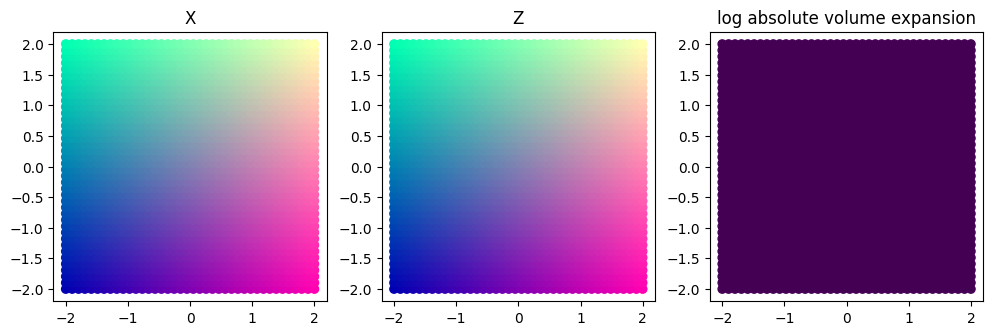

In [6]:
fig, (axl, axm, axr) = plt.subplots(1, 3, figsize=(12, 3.5))
axl.scatter(*grid.T, c=grid_color)
axl.set_title('X')
axm.scatter(*z.detach().cpu().T, c=grid_color)
axm.set_title('Z')
pos = axr.scatter(*z.detach().cpu().T, c=ldj.detach().cpu())
axr.set_title('log absolute volume expansion')
# fig.colorbar(pos, ax=axr)
plt.show()

In [41]:
reconstr, ldj_inv = model.inverse_and_log_det(z)

In [7]:
def psd_mat_sqrt(mats: torch.Tensor):
    eigvals, eigvecs = torch.linalg.eigh(mats)
    return torch.einsum('kid, kd, kdj -> kij', eigvecs, torch.sqrt(eigvals), eigvecs.swapaxes(-2, -1))
def unit_circle(resolution: int = 32):
    t = torch.linspace(0, 2*torch.pi, resolution+1)
    return torch.stack((torch.cos(t), torch.sin(t)), dim=-1)
def plot_2d_gmm(means: torch.Tensor, covs: torch.Tensor, scale_fac=1.5, resolution: int=32, color='k'):
    means, covs = means.detach().cpu(), covs.detach().cpu()
    ellipsoids = scale_fac*torch.einsum('kid,rd->irk', psd_mat_sqrt(covs), unit_circle(resolution)) + means.T[:, None, :]
    plt.plot(*ellipsoids, c=color)

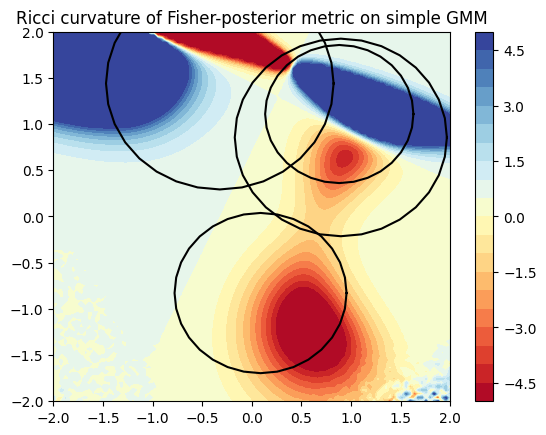

In [8]:
k=4
means_rdm = torch.randn(k, 2)
# covs_rdm = (0.5*torch.randn(k, 2, 2))
# covs_rdm = torch.einsum('kli,klj->kij', covs_rdm, covs_rdm)
covs_rdm = (0.4+0.25*torch.randn(k))[:, None, None] * torch.eye(2)
gmm_rdm = ConditionalGMM(2, k, means=means_rdm, covs=covs_rdm)
gmm_cuda_rdm = ConditionalGMM(2, k, means=means_rdm.cuda(), covs=covs_rdm.cuda())
M_rdm = FisherLogPosteriorManifold(gmm_cuda_rdm.log_posterior)
X_c, Y_c = torch.linspace(-2, 2, 100), torch.linspace(-2, 2, 100) #type:ignore
grid_c = torch.stack(torch.meshgrid(X_c, Y_c, indexing='xy')).movedim(0, -1)
ric_grid_c = torch.clamp(M_rdm.ric(grid_c.cuda()).detach().cpu(), min=-5, max=5)
plt.contourf(X_c, Y_c, ric_grid_c, cmap='RdYlBu', levels=20) #type:ignore
plt.colorbar()
plt.title('Ricci curvature of Fisher-posterior metric on simple GMM')
plot_2d_gmm(gmm_rdm.means, gmm_rdm.covs)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.show()

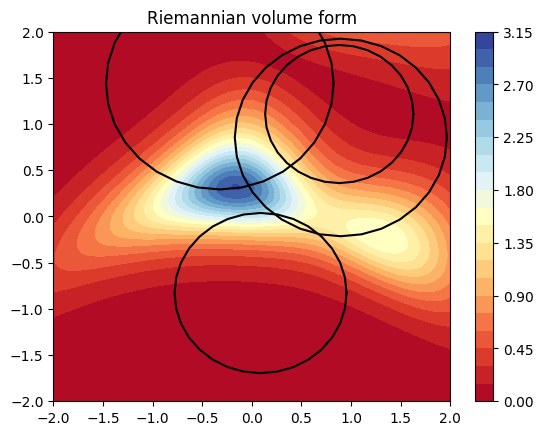

In [28]:
vol_grid_c = torch.clamp(torch.sqrt(torch.linalg.det(M_rdm.g(grid_c.cuda()).detach())).cpu(), min=-5, max=5)
plt.contourf(X_c, Y_c, vol_grid_c, cmap='RdYlBu', levels=20) #type:ignore
plt.colorbar()
plt.title('Riemannian volume form')
plot_2d_gmm(gmm_rdm.means, gmm_rdm.covs)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.show()

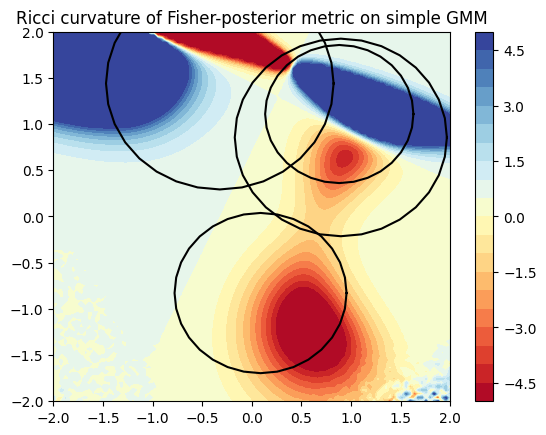

In [27]:
ric_grid_c = torch.clamp(M_rdm.ric(grid_c.cuda()).detach().cpu(), min=-5, max=5)
plt.contourf(X_c, Y_c, ric_grid_c, cmap='RdYlBu', levels=20) #type:ignore
plt.colorbar()
plt.title('Ricci curvature of Fisher-posterior metric on simple GMM')
plot_2d_gmm(gmm_rdm.means, gmm_rdm.covs)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.show()

In [57]:
gmm_cuda_rdm.means

tensor([[-0.3219,  1.4397],
        [ 0.8980,  0.8553],
        [ 0.8824,  1.1087],
        [ 0.0888, -0.8288]], device='cuda:0')

In [24]:
tet_vertices = torch.tensor((
    (1., 1., 1.),
    (1., -1., -1.),
    (-1., 1., -1.),
    (-1., -1., 1.),
))
immersed = gmm_cuda_rdm.posterior(grid_c.cuda()).cpu() @ tet_vertices

In [56]:
torch.save((immersed, vol_grid_c, ric_grid_c), 'pickled_objects/immersion_data.pt')

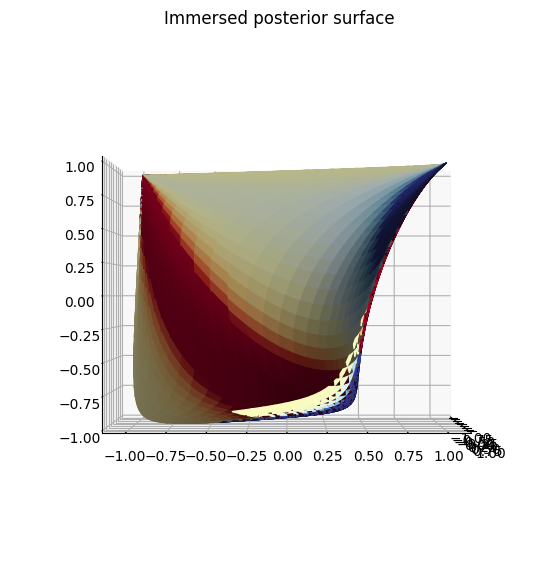

In [55]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(*immersed.movedim(-1, 0), facecolors=cm.RdYlBu(ric_grid_c))
ax.set_title('Immersed posterior surface')
ax.view_init(elev=0, azim=0)
plt.show()

In [ ]:
log_vol_grid = torch.log(vol_grid_c)

In [117]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
mse = torch.nn.MSELoss()

In [9]:
grid_cuda = grid.cuda()
ric_grid = torch.clamp(M_rdm.ric(grid_cuda).detach(), min=-5, max=5)

In [124]:
n_iters = 100
for _ in trange(n_iters, desc='Optimizing coordinate transformation'):
    optimizer.zero_grad()
    z, ldj = model.forward_and_log_det(grid_cuda)
    loss = mse(-ric_grid, ldj)
    loss.backward()
    optimizer.step()

Optimizing coordinate transformation: 100%|██████████| 100/100 [00:03<00:00, 26.49it/s]


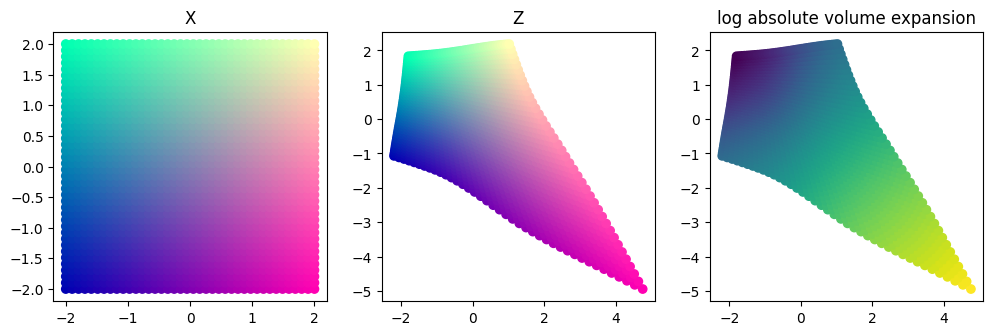

In [125]:
z, ldj = model.forward_and_log_det(grid_cuda)
fig, (axl, axm, axr) = plt.subplots(1, 3, figsize=(12, 3.5))
axl.scatter(*grid.T, c=grid_color)
axl.set_title('X')
axm.scatter(*z.detach().cpu().T, c=grid_color)
axm.set_title('Z')
pos = axr.scatter(*z.detach().cpu().T, c=ldj.detach().cpu())
axr.set_title('log absolute volume expansion')
# fig.colorbar(pos, ax=axr)
plt.show()